# Task 1 - Spatial Feature Engineering for Earthquake Data

In [1]:

import warnings, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import gaussian_kde
from scipy.spatial import cKDTree
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KernelDensity
import geopandas as gpd
from shapely.geometry import Point

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.edgecolor':   '#cccccc',
    'axes.labelcolor':  'black',
    'xtick.color':      'black',
    'ytick.color':      'black',
    'grid.color':       '#dddddd',
    'text.color':       'black',
    'figure.dpi':       120,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})
CMAP = 'plasma'
os.makedirs('feature_engineering', exist_ok=True)

import geopandas as gpd
import matplotlib.pyplot as plt

# Global cache for the map
_WORLD_DATA = None

def get_world_map():
    global _WORLD_DATA
    if _WORLD_DATA is None:
        print("Downloading base map... (This happens only once)")
        try:
            
            url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
            _WORLD_DATA = gpd.read_file(url)
        except Exception as e:
            print(f"Map download failed: {e}")
            _WORLD_DATA = gpd.GeoDataFrame()
    return _WORLD_DATA

def add_world_map(ax, ocean='#ffffff', land='#f0f0e8', border='#777777'):
    ax.set_facecolor(ocean)
    world = get_world_map()
    if not world.empty:
        # We plot the map as a static background
        world.plot(ax=ax, color=land, edgecolor=border, linewidth=0.3, zorder=1)
    ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
    ax.grid(False)


In [2]:

df = pd.read_csv('final_preprocessed_earthquake_data.csv', low_memory=False)
df['time'] = pd.to_datetime(df['time'], errors='coerce', utc=True)
df = df.dropna(subset=['latitude','longitude','mag','depth'])
df = df[df['mag'] >= 4.5].copy()
df = df.reset_index(drop=True)
print(f"Shape: {df.shape}")
print(df.dtypes)
df.head(3)


Shape: (175946, 47)
time                       datetime64[ns, UTC]
latitude                               float64
longitude                              float64
depth                                  float64
mag                                    float64
magType                                 object
nst                                    float64
gap                                    float64
rms                                    float64
net                                     object
id                                      object
updated                                 object
place                                   object
type                                    object
status                                  object
year                                     int64
month                                    int64
day                                      int64
hour                                     int64
day_of_week                              int64
month_sin                              f

,time,latitude,longitude,depth,mag,magType,nst,gap,rms,net,...,lat_bin,lon_bin,grid_id,spatial_lag_mag,spatial_lag_depth,local_heterogeneity_mag,moran_quadrant,day_of_year,season,lisa_cluster
0,2000-01-01 11:22:57+00:00,46.888,-78.930,18.0,4.7,mb,0.0,0.0,0.00,us,...,13,10,13_10,0.209483,13.604,0.059376,Low-High (Spatial Outlier),1,Winter,Low-High (Outlier)
1,NaT,16.070,-94.513,42.2,4.8,mb,0.0,0.0,0.93,us,...,10,8,10_8,-0.075390,57.992,0.016000,Low-Low (Coldspot),10,Winter,Low-Low (Coldspot)
2,NaT,8.449,-83.148,10.0,4.6,mb,0.0,0.0,1.10,us,...,9,9,9_9,0.701537,18.016,0.198400,Low-High (Spatial Outlier),14,Winter,Low-High (Outlier)


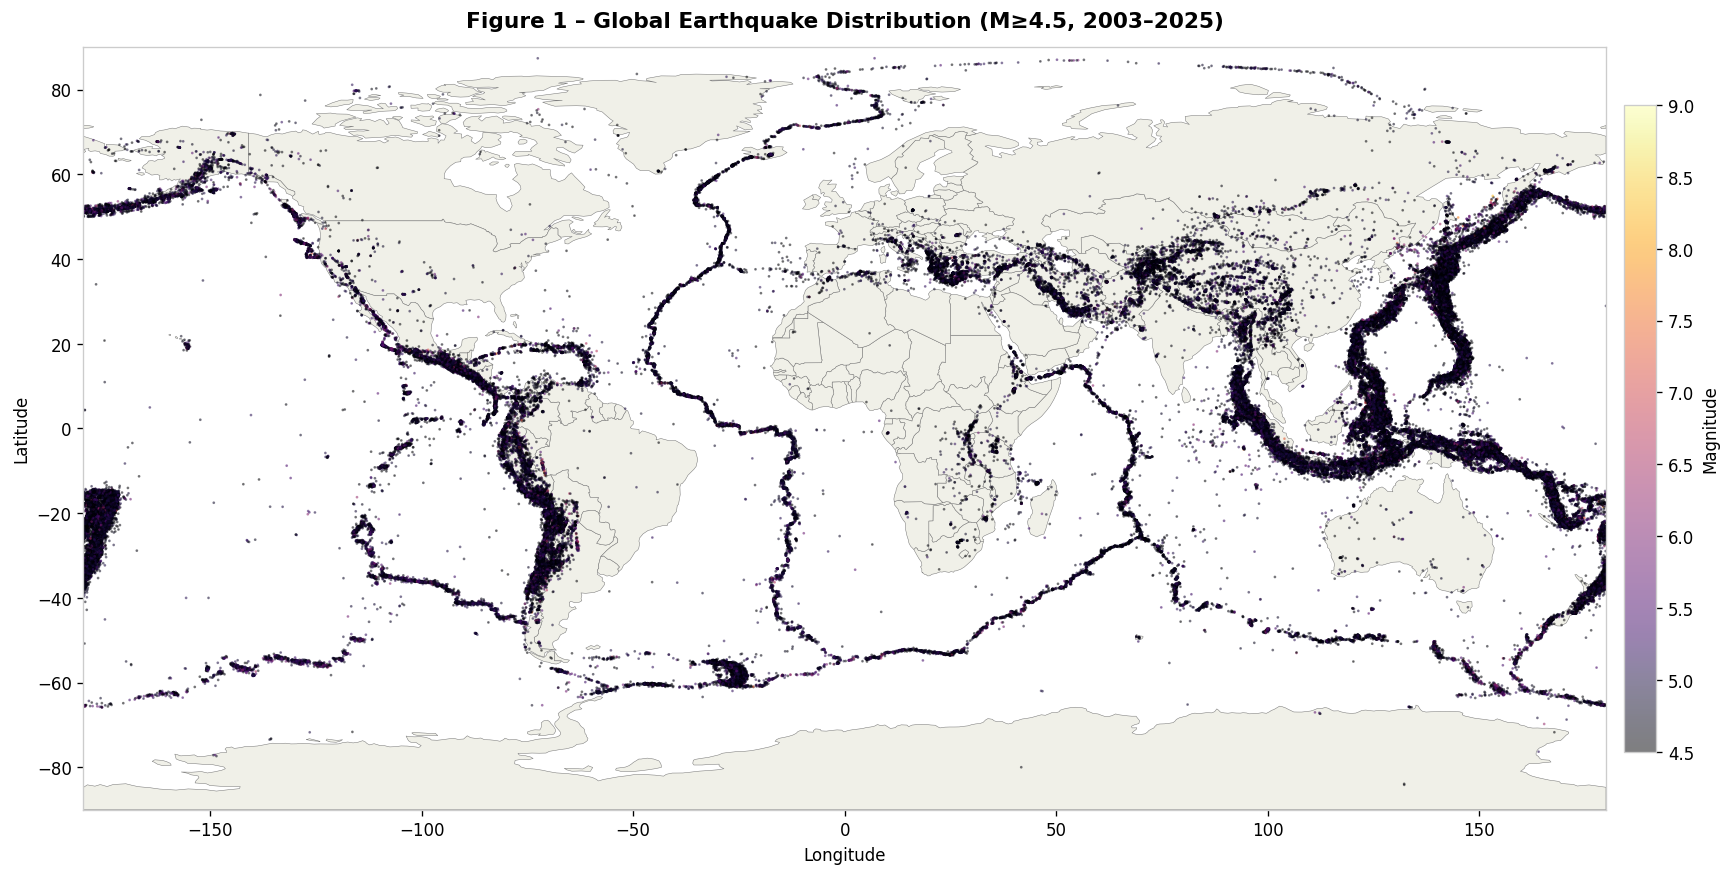

In [3]:

# VIZ 1 – Global Earthquake Distribution 
fig, ax = plt.subplots(figsize=(16,8))
add_world_map(ax)
sc = ax.scatter(df['longitude'], df['latitude'],
                c=df['mag'], cmap='inferno', s=0.4, alpha=0.5,
                vmin=4.5, vmax=9, zorder=2)
cb = fig.colorbar(sc, ax=ax, pad=0.01, shrink=0.7)
cb.set_label('Magnitude')
ax.set_title('Figure 1 – Global Earthquake Distribution (M≥4.5, 2003–2025)', pad=12)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('feature_engineering/fig01_global_map.png', dpi=150, bbox_inches='tight')
plt.show()


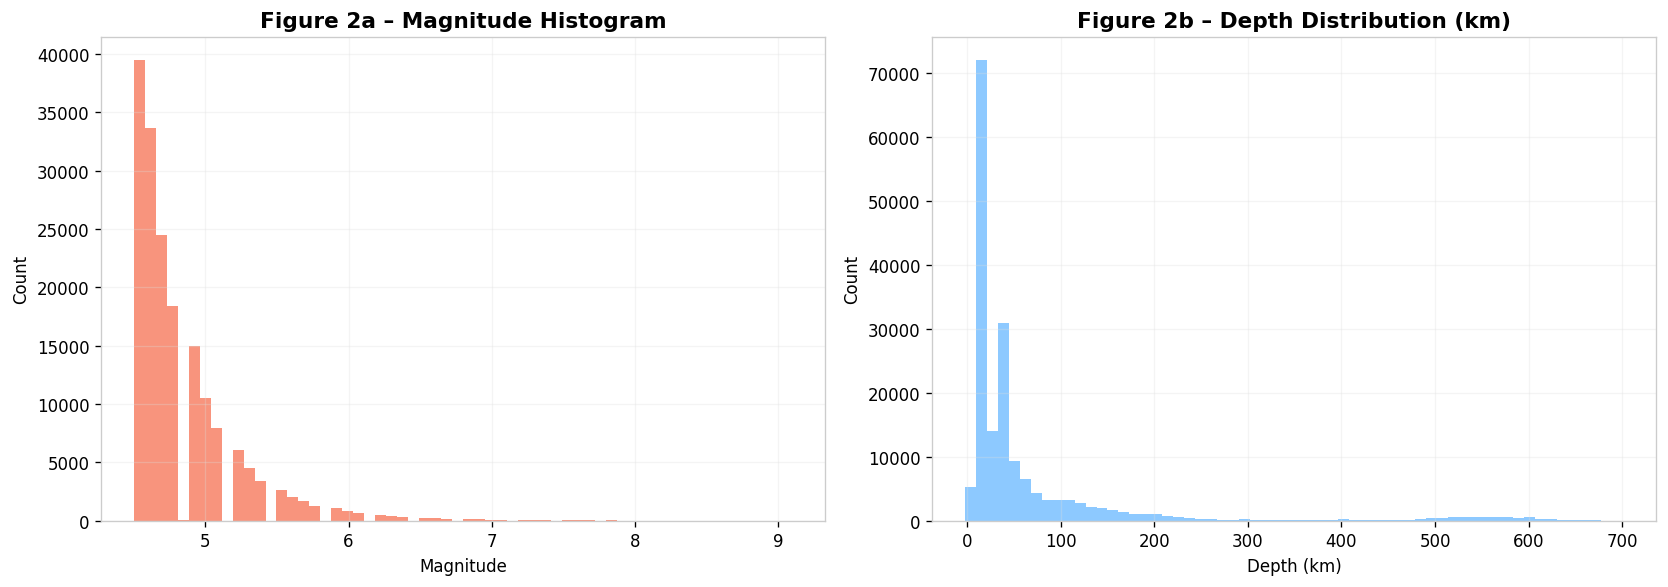

In [4]:

# VIZ 2 – Magnitude Distribution
fig, axes = plt.subplots(1,2, figsize=(14,5))
axes[0].hist(df['mag'], bins=60, color='#f78166', edgecolor='none', alpha=0.85)
axes[0].set_title('Figure 2a – Magnitude Histogram')
axes[0].set_xlabel('Magnitude'); axes[0].set_ylabel('Count')

axes[1].hist(df['depth'], bins=60, color='#79c0ff', edgecolor='none', alpha=0.85)
axes[1].set_title('Figure 2b – Depth Distribution (km)')
axes[1].set_xlabel('Depth (km)'); axes[1].set_ylabel('Count')
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('feature_engineering/fig02_histograms.png', dpi=150, bbox_inches='tight')
plt.show()


In [5]:

# FEATURE 1 – depth_category
def categorize_depth(d):
    if d < 70: return 'Shallow'
    elif d < 300: return 'Intermediate'
    else: return 'Deep'

df['depth_category'] = df['depth'].apply(categorize_depth)
print(df['depth_category'].value_counts())


depth_category
Shallow         138861
Intermediate     28801
Deep              8284
Name: count, dtype: int64


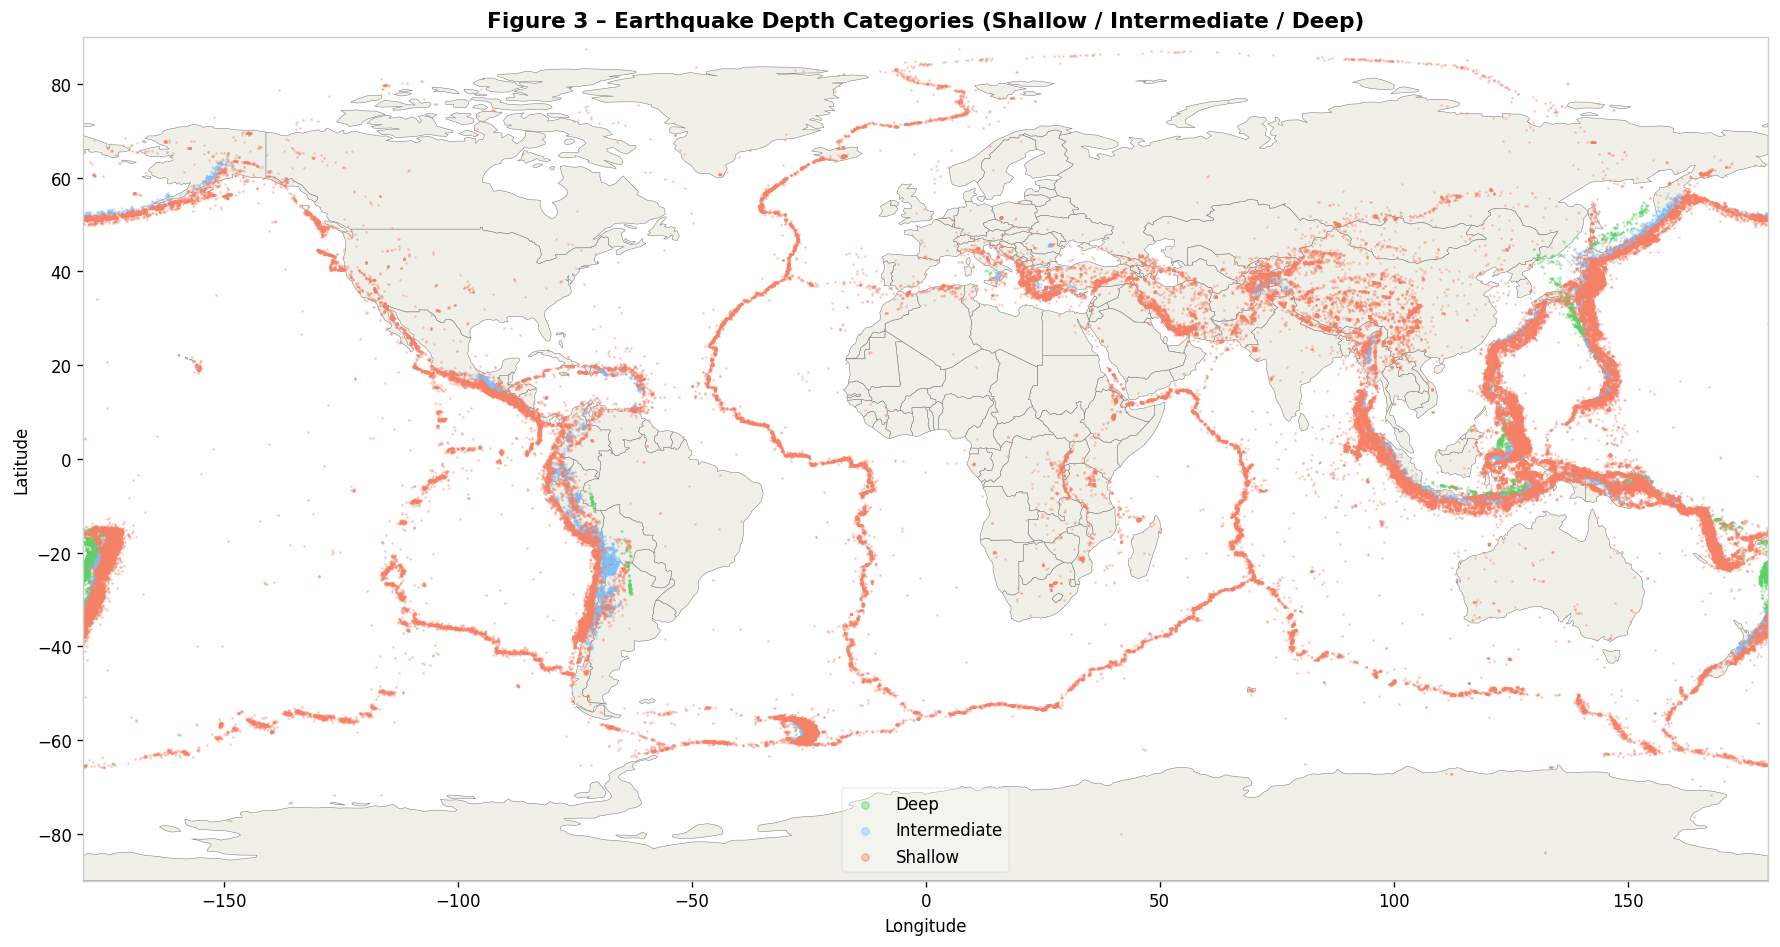

In [6]:

# VIZ 3 – Depth Category Map
cat_colors = {'Shallow':'#f78166', 'Intermediate':'#79c0ff', 'Deep':'#56d364'}
fig, ax = plt.subplots(figsize=(16,8))
add_world_map(ax)
for cat, grp in df.groupby('depth_category'):
    ax.scatter(grp['longitude'], grp['latitude'],
               c=cat_colors[cat], s=0.3, alpha=0.4, label=cat)
ax.legend(markerscale=8, framealpha=0.3)
ax.set_title('Figure 3 – Earthquake Depth Categories (Shallow / Intermediate / Deep)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('feature_engineering/fig03_depth_category_map.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:

# FEATURE 2 – grid_cell_id (0.5° regular grid)
GRID = 0.5
df['grid_lat'] = (df['latitude']  // GRID) * GRID
df['grid_lon'] = (df['longitude'] // GRID) * GRID
df['grid_cell_id'] = df['grid_lat'].astype(str) + '_' + df['grid_lon'].astype(str)

# count per cell
grid_count = df.groupby(['grid_lat','grid_lon']).size().reset_index(name='count')
print(f"Unique grid cells: {df['grid_cell_id'].nunique()}")
grid_count.head()


Unique grid cells: 16925


,grid_lat,grid_lon,count
0,-84.5,132.0,1
1,-84.0,132.0,1
2,-80.0,41.5,1
3,-77.5,-149.5,1
4,-77.5,-149.0,2


In [8]:

# FEATURE 3 – spatial_density via KDE (sampled for speed)
from sklearn.neighbors import KernelDensity

sample = df.sample(min(30000, len(df)), random_state=42)
coords_s = sample[['latitude','longitude']].values
kde = KernelDensity(bandwidth=2.0, metric='haversine')
kde.fit(np.radians(coords_s))
log_dens = kde.score_samples(np.radians(coords_s))
sample['kde_density'] = np.exp(log_dens)

# Assign back (approximate)
df['spatial_density'] = np.nan
df.loc[sample.index, 'spatial_density'] = sample['kde_density']
df['spatial_density'] = df['spatial_density'].fillna(df['spatial_density'].median())
print("KDE density computed ")
sample[['latitude','longitude','kde_density']].head()


KDE density computed 


,latitude,longitude,kde_density
173544,31.2791,49.7242,0.028139
107139,51.6267,-173.3639,0.031218
145245,50.7100,175.5980,0.031518
2713,7.0750,-104.3670,0.027190
126307,2.4910,96.2800,0.031464


In [9]:

# FEATURE 4 – regional_mag_mean (mean magnitude per grid cell)
grid_mag = df.groupby('grid_cell_id')['mag'].mean().rename('regional_mag_mean')
df = df.join(grid_mag, on='grid_cell_id')
print("regional_mag_mean stats:\n", df['regional_mag_mean'].describe())


regional_mag_mean stats:
 count    175946.000000
mean          4.829119
std           0.146053
min           4.500000
25%           4.746939
50%           4.815414
75%           4.887160
max           7.700000
Name: regional_mag_mean, dtype: float64


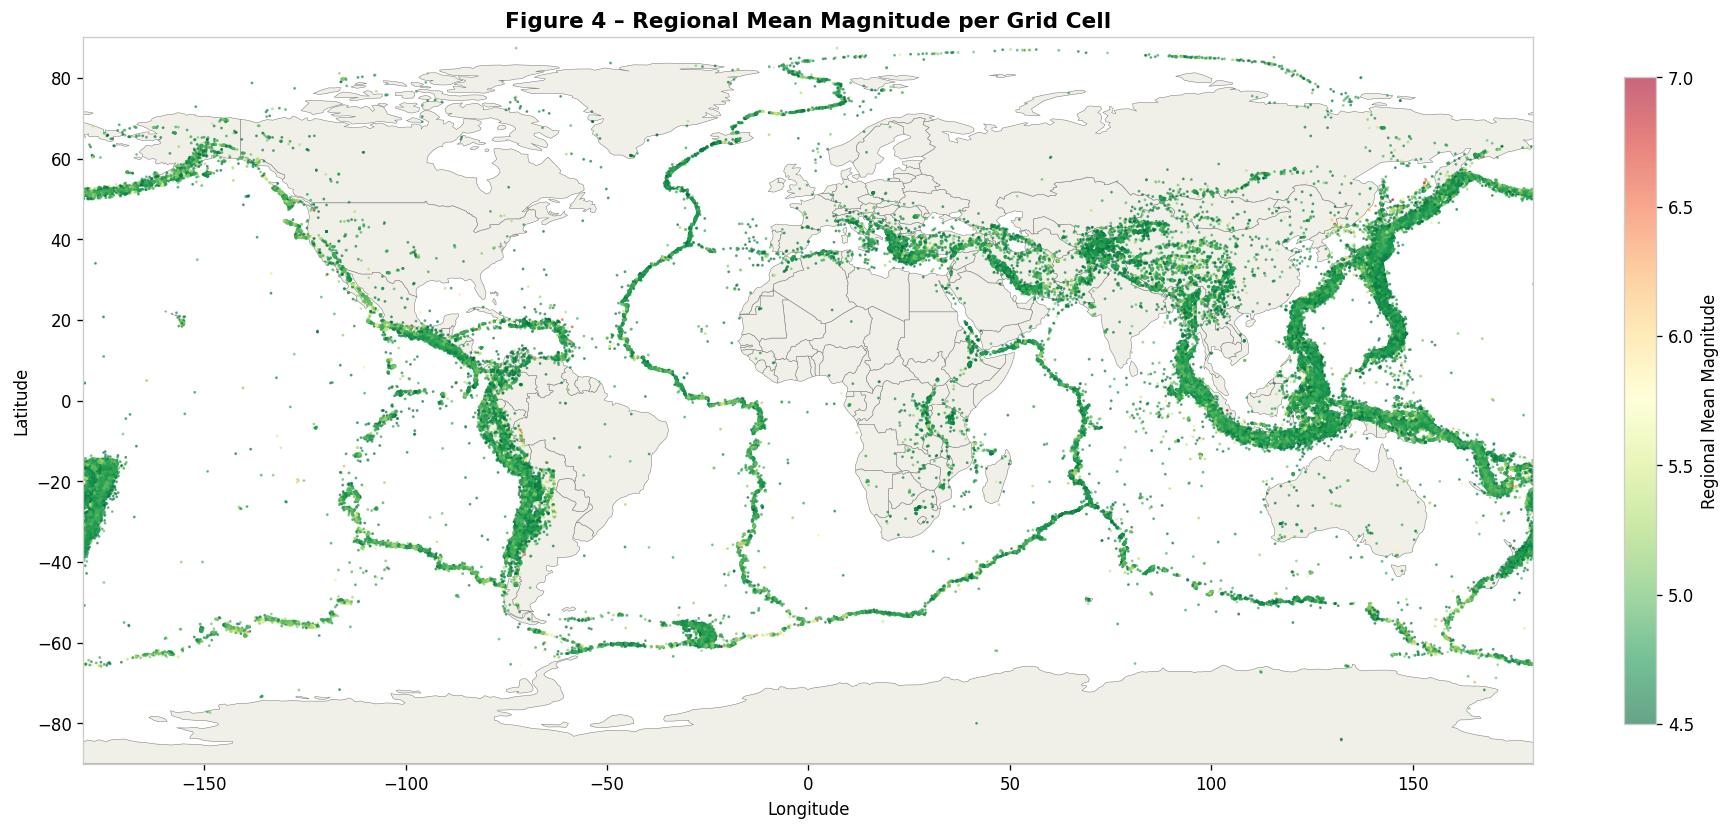

In [10]:

# VIZ 4 – Regional Magnitude Mean Map
sub = df.dropna(subset=['regional_mag_mean'])
fig, ax = plt.subplots(figsize=(16,8))
add_world_map(ax)
sc = ax.scatter(sub['longitude'], sub['latitude'],
                c=sub['regional_mag_mean'], cmap='RdYlGn_r', s=0.5, alpha=0.6, vmin=4.5, vmax=7)
cb = fig.colorbar(sc, ax=ax, shrink=0.7)
cb.set_label('Regional Mean Magnitude')
ax.set_title('Figure 4 – Regional Mean Magnitude per Grid Cell')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('feature_engineering/fig04_regional_mag.png', dpi=150, bbox_inches='tight')
plt.show()


In [11]:

# FEATURE 5 – focal_mechanism_proxy
# Heuristic: depth + absolute latitude → tectonic regime hint
def focal_proxy(row):
    if row['depth'] < 30 and abs(row['latitude']) < 20:
        return 'Subduction_shallow'
    elif 30 <= row['depth'] < 100:
        return 'Subduction_intermediate'
    elif row['depth'] >= 100:
        return 'Deep_slab'
    else:
        return 'Crustal'

df['focal_mechanism_proxy'] = df.apply(focal_proxy, axis=1)
print(df['focal_mechanism_proxy'].value_counts())


focal_mechanism_proxy
Subduction_intermediate    61343
Crustal                    51884
Subduction_shallow         34409
Deep_slab                  28310
Name: count, dtype: int64


In [12]:

# FEATURE 6 – tectonic_zone (simplified plate-zone proxy)
def tectonic_zone(row):
    lat, lon = row['latitude'], row['longitude']
    # Ring of Fire - Pacific rim
    if (lat > 0 and 120 < lon < 180) or (lat > 0 and -180 < lon < -60):
        return 'Pacific_RingOfFire_N'
    if (lat < 0 and 120 < lon < 180) or (lat < 0 and -180 < lon < -60):
        return 'Pacific_RingOfFire_S'
    if -20 < lat < 40 and 20 < lon < 80:
        return 'Alpine_Himalayan'
    if -60 < lat < 0 and -70 < lon < -10:
        return 'South_American'
    if -5 < lat < 5 and -40 < lon < 0:
        return 'Mid_Atlantic_Ridge'
    return 'Other'

df['tectonic_zone'] = df.apply(tectonic_zone, axis=1)
print(df['tectonic_zone'].value_counts())


tectonic_zone
Pacific_RingOfFire_S    73922
Pacific_RingOfFire_N    55094
Other                   29191
Alpine_Himalayan        10424
South_American           6821
Mid_Atlantic_Ridge        494
Name: count, dtype: int64


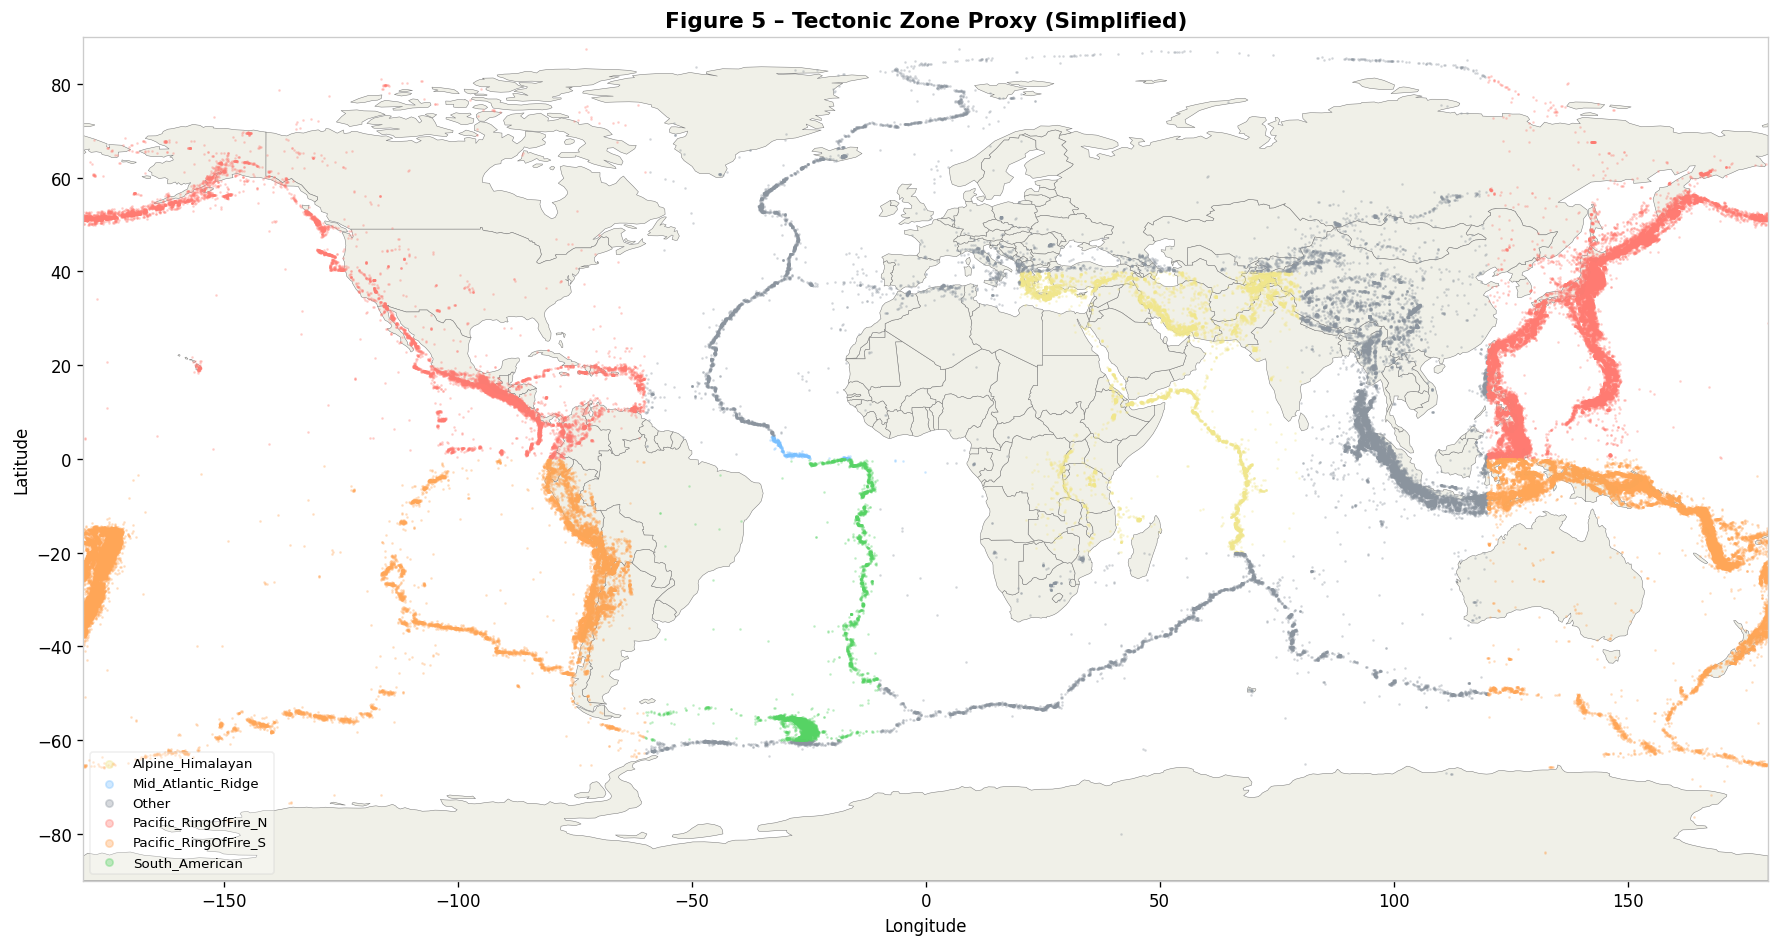

In [13]:

# VIZ 5 – Tectonic Zone Map
tz_pal = {'Pacific_RingOfFire_N':'#ff7b72','Pacific_RingOfFire_S':'#ffa657',
          'Alpine_Himalayan':'#f0e68c','South_American':'#56d364',
          'Mid_Atlantic_Ridge':'#79c0ff','Other':'#8b949e'}
fig, ax = plt.subplots(figsize=(16,8))
add_world_map(ax)
for tz, grp in df.groupby('tectonic_zone'):
    ax.scatter(grp['longitude'], grp['latitude'],
               c=tz_pal.get(tz,'#8b949e'), s=0.3, alpha=0.35, label=tz)
ax.legend(markerscale=8, framealpha=0.3, fontsize=8, loc='lower left')
ax.set_title('Figure 5 – Tectonic Zone Proxy (Simplified)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('feature_engineering/fig05_tectonic_zone.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:

# FEATURE 7 – spatial_lag_mag (weighted average of neighbours using KDTree)
# Use a sample for speed
samp2 = df.sample(min(50000, len(df)), random_state=7).copy()
coords_r = np.radians(samp2[['latitude','longitude']].values)
tree = cKDTree(coords_r)
dists, idxs = tree.query(coords_r, k=6)   # nearest 5 neighbours + self
# weighted mean (weight = 1/dist, skip self)
sp_lag = []
for i in range(len(samp2)):
    nbr_idx = idxs[i][1:]  # skip self
    nbr_d   = dists[i][1:]
    w = 1 / (nbr_d + 1e-9)
    sp_lag.append(np.average(samp2['mag'].values[nbr_idx], weights=w))
samp2['spatial_lag_mag'] = sp_lag
df['spatial_lag_mag'] = np.nan
df.loc[samp2.index, 'spatial_lag_mag'] = samp2['spatial_lag_mag']
df['spatial_lag_mag'].fillna(df['spatial_lag_mag'].median(), inplace=True)
print("Spatial lag mag computed ")
print(samp2['spatial_lag_mag'].describe())


Spatial lag mag computed 
count    50000.000000
mean         4.836348
std          0.216106
min          4.500000
25%          4.684093
50%          4.792579
75%          4.938543
max          6.969680
Name: spatial_lag_mag, dtype: float64


In [15]:

# FEATURE 8 – dist_to_nearest_km  (approx using haversine)
EARTH_R = 6371.0
# distances from tree query already in radians → convert to km
nn_dist_rad = dists[:, 1]   # nearest neighbour (skip self)
samp2['dist_to_nearest_km'] = nn_dist_rad * EARTH_R
df['dist_to_nearest_km'] = np.nan
df.loc[samp2.index, 'dist_to_nearest_km'] = samp2['dist_to_nearest_km']
df['dist_to_nearest_km'].fillna(df['dist_to_nearest_km'].median(), inplace=True)
print("dist_to_nearest_km computed ")
print(samp2['dist_to_nearest_km'].describe())


dist_to_nearest_km computed 
count    50000.000000
mean        14.346546
std         44.679627
min          0.000000
25%          3.507420
50%          6.656064
75%         12.922896
max       3310.876008
Name: dist_to_nearest_km, dtype: float64


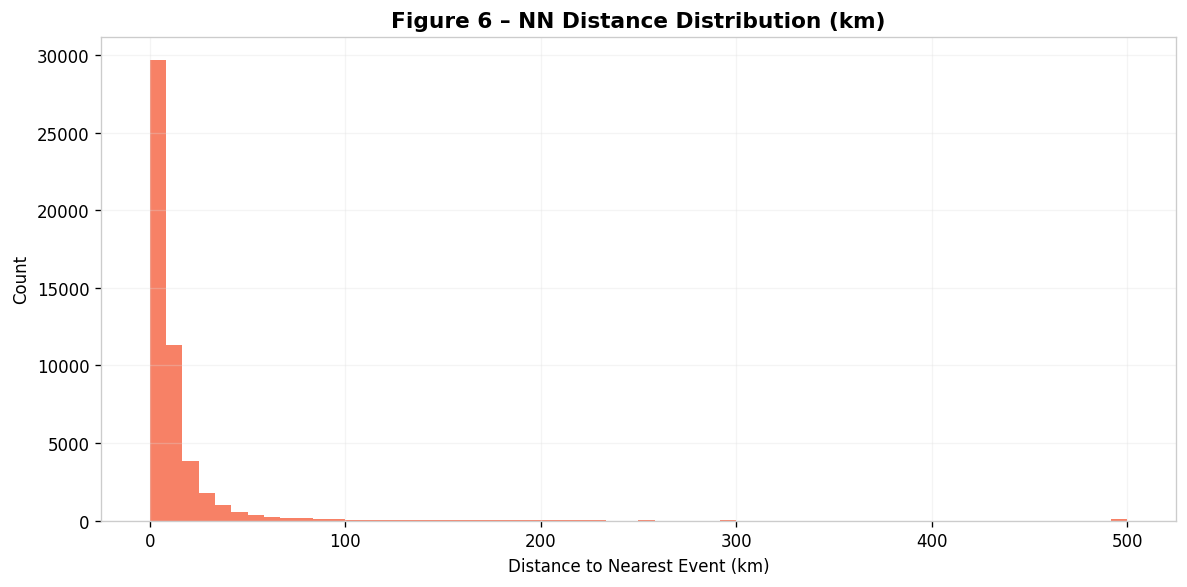

In [16]:

# VIZ 6 – Distance to Nearest Neighbour
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(samp2['dist_to_nearest_km'].clip(0,500), bins=60, color='#f78166', edgecolor='none')
ax.set_xlabel('Distance to Nearest Event (km)')
ax.set_ylabel('Count')
ax.set_title('Figure 6 – NN Distance Distribution (km)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('feature_engineering/fig6_nn_dist.png', dpi=150, bbox_inches='tight')
plt.show()


In [17]:

# FEATURE 9 – geohash-inspired 2° bucket for neighbourhood analysis
df['geo_bucket'] = (df['latitude'].round(0)).astype(str)+'_'+(df['longitude'].round(0)).astype(str)
bucket_stats = df.groupby('geo_bucket').agg(
    event_count=('mag','count'),
    mean_mag=('mag','mean'),
    max_mag=('mag','max')
).reset_index()
print(f"Unique geo_buckets: {df['geo_bucket'].nunique()}")
bucket_stats.sort_values('event_count', ascending=False).head(10)


Unique geo_buckets: 7823


,geo_bucket,event_count,mean_mag,max_mag
2262,-5.0_153.0,865,4.891098,7.8
1390,-30.0_-177.0,840,4.805952,8.1
3107,-7.0_155.0,749,4.825501,7.5
1391,-30.0_-178.0,685,4.867883,7.4
621,-18.0_-178.0,665,4.733835,8.2
4314,24.0_122.0,661,4.856127,7.4
3415,1.0_97.0,659,4.743703,6.2
7627,8.0_94.0,654,4.812538,6.4
261,-11.0_166.0,640,4.865000,7.1
2588,-56.0_-27.0,632,4.837342,7.2


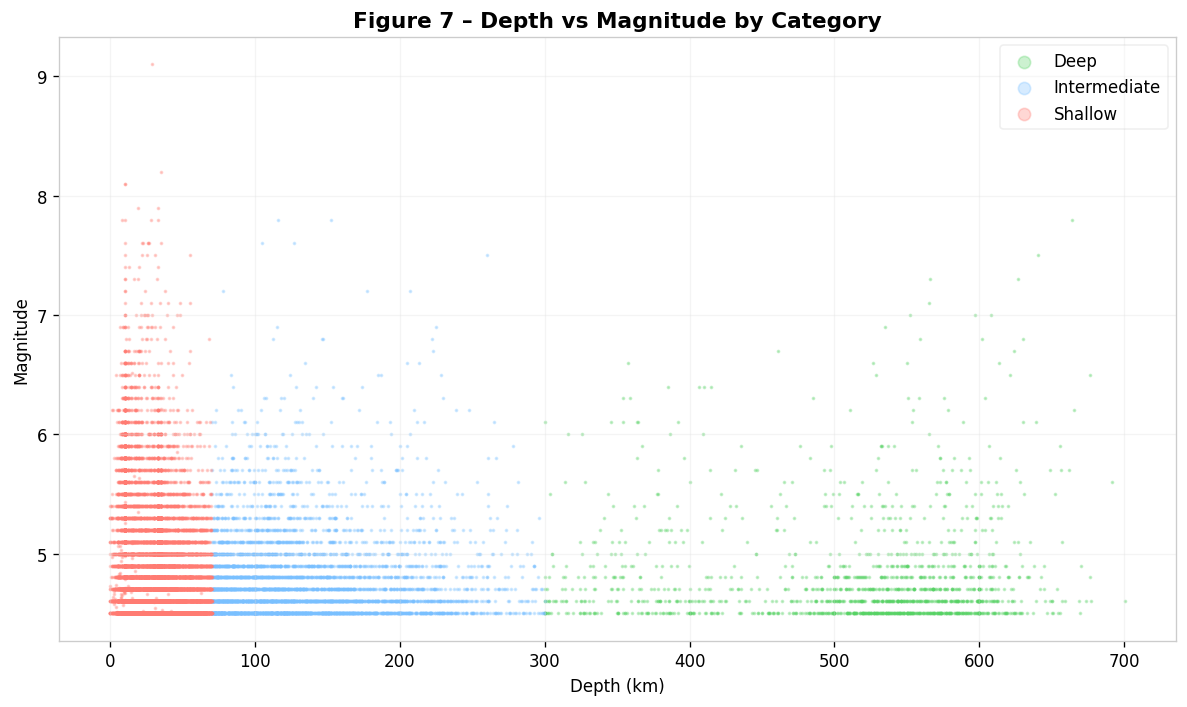

In [18]:

# VIZ 7 – Depth vs Magnitude (coloured by depth category)
sub14 = df.sample(30000, random_state=14)
cat_c = {'Shallow':'#ff7b72','Intermediate':'#79c0ff','Deep':'#56d364'}
fig, ax = plt.subplots(figsize=(10,6))
for cat, grp in sub14.groupby('depth_category'):
    ax.scatter(grp['depth'], grp['mag'], c=cat_c[cat], s=1.5, alpha=0.3, label=cat)
ax.set_xlabel('Depth (km)'); ax.set_ylabel('Magnitude')
ax.set_title('Figure 7 – Depth vs Magnitude by Category')
ax.legend(markerscale=6, framealpha=0.3)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('feature_engineering/fig07_depth_vs_mag.png', dpi=150, bbox_inches='tight')
plt.show()


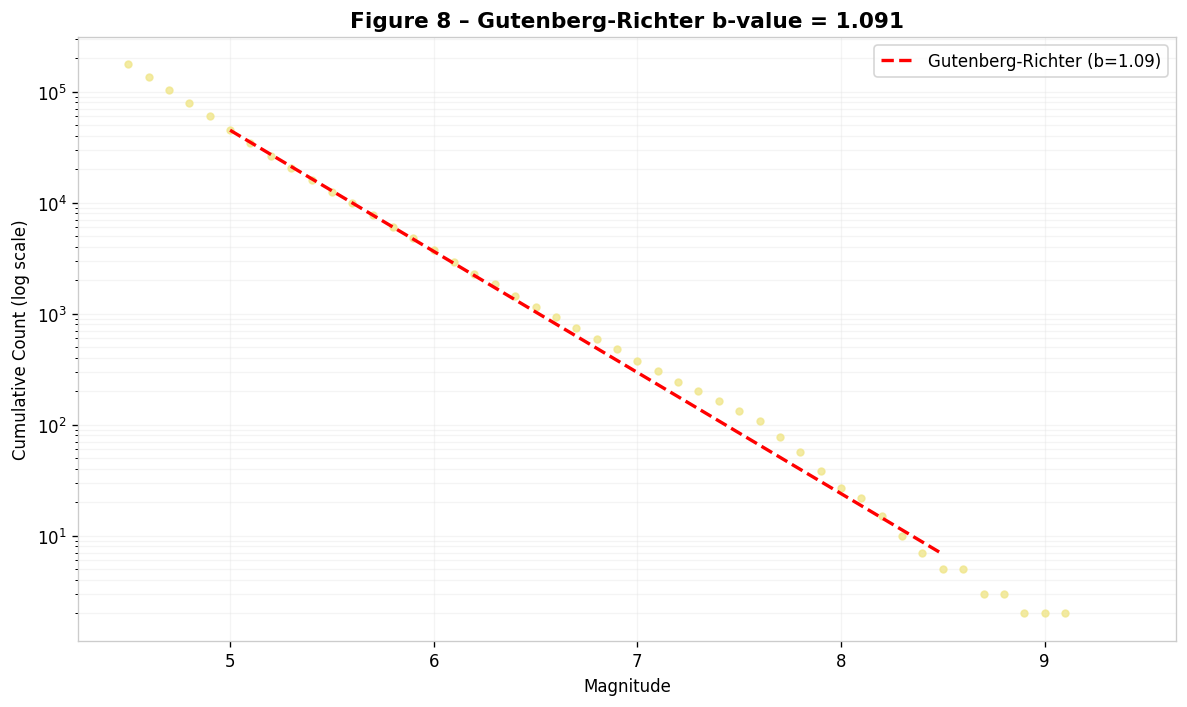

In [19]:

# VIZ 8 – Gutenberg-Richter Magnitude-Frequency (log scale)
mag_bins = np.arange(4.5, 9.5, 0.1)
counts = [(df['mag'] >= m).sum() for m in mag_bins]
fig, ax = plt.subplots(figsize=(10,6))
ax.semilogy(mag_bins, counts, 'o', color='#f0e68c', ms=4, alpha=0.8)

# Fit b-value via MLE (simple)
m_min = 5.0
sub_gr = df[df['mag'] >= m_min]['mag']
b_val = np.log10(np.e) / (sub_gr.mean() - m_min + 0.05)
m_fit = np.linspace(m_min, 8.5, 100)
N_fit = len(sub_gr) * 10**(-b_val*(m_fit - m_min))
ax.semilogy(m_fit, N_fit, 'r--', lw=2, label=f'Gutenberg-Richter (b={b_val:.2f})')

ax.set_xlabel('Magnitude'); ax.set_ylabel('Cumulative Count (log scale)')
ax.set_title(f'Figure 8 – Gutenberg-Richter b-value = {b_val:.3f}')
ax.legend(); ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('feature_engineering/fig08_gutenberg_richter.png', dpi=150, bbox_inches='tight')
plt.show()


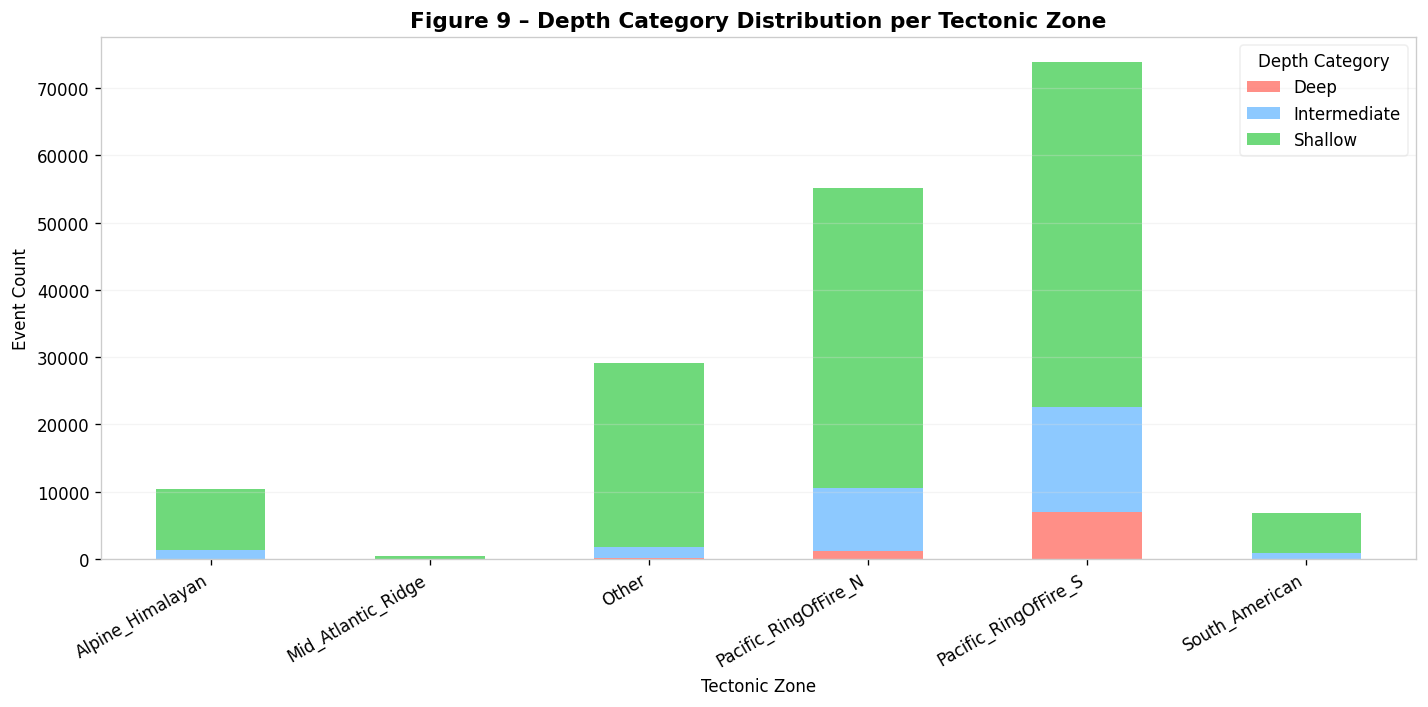

In [20]:

# VIZ 9 – Stacked bar: tectonic zone × depth category
ct = pd.crosstab(df['tectonic_zone'], df['depth_category'])
fig, ax = plt.subplots(figsize=(12,6))
ct.plot(kind='bar', stacked=True, ax=ax,
        color=['#ff7b72','#79c0ff','#56d364'], alpha=0.85)
ax.set_xlabel('Tectonic Zone')
ax.set_ylabel('Event Count')
ax.set_title('Figure 9 – Depth Category Distribution per Tectonic Zone')
ax.legend(title='Depth Category', framealpha=0.3)
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('feature_engineering/fig09_depth_tectonic.png', dpi=150, bbox_inches='tight')
plt.show()


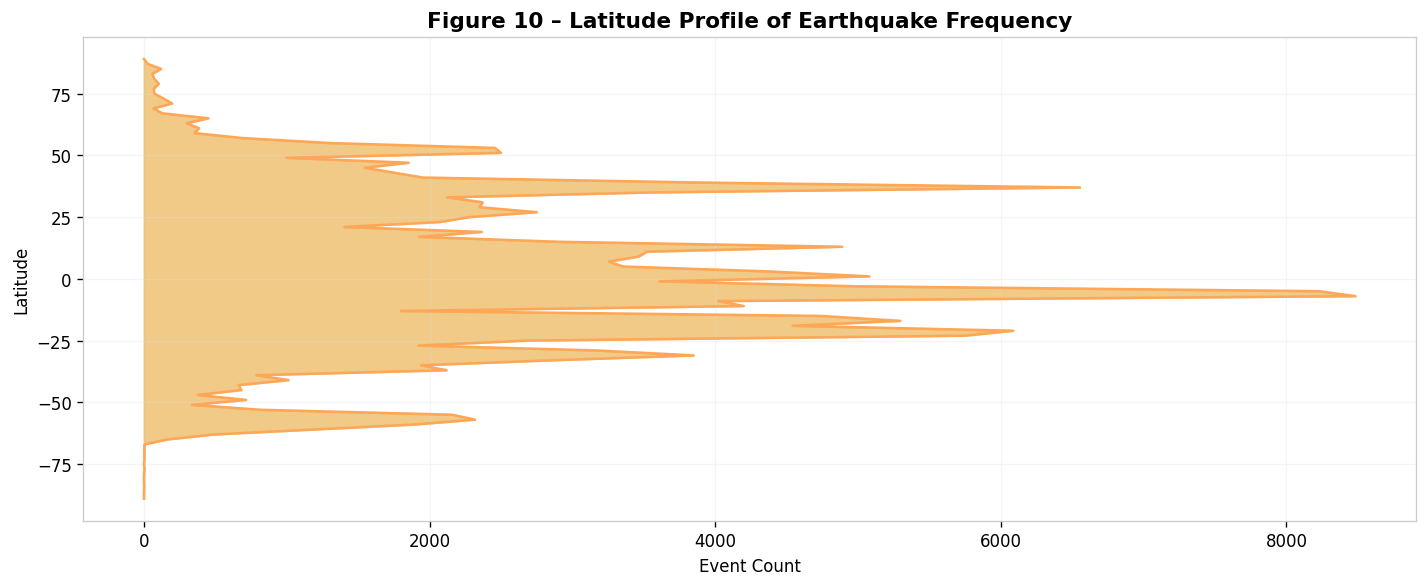

In [21]:

# VIZ 10 – Latitude Profile of Event Frequency
lat_bins = np.arange(-90,91,2)
lat_centers = (lat_bins[:-1]+lat_bins[1:])/2
lat_count = [((df['latitude']>=lo) & (df['latitude']<hi)).sum()
             for lo, hi in zip(lat_bins[:-1],lat_bins[1:])]
fig, ax = plt.subplots(figsize=(12,5))
ax.fill_betweenx(lat_centers, lat_count, color='#e8a838', alpha=0.6)
ax.plot(lat_count, lat_centers, color='#ffa657', lw=1.5)
ax.set_xlabel('Event Count'); ax.set_ylabel('Latitude')
ax.set_title('Figure 10 – Latitude Profile of Earthquake Frequency')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('feature_engineering/fig10_lat_profile.png', dpi=150, bbox_inches='tight')
plt.show()


In [22]:

# FEATURE SUMMARY
feat_summary = pd.DataFrame({
    'Feature': ['depth_category','grid_cell_id','spatial_density','regional_mag_mean',
                'focal_mechanism_proxy','tectonic_zone','spatial_lag_mag',
                'dist_to_nearest_km','geo_bucket'],
    'Type': ['Categorical','Categorical','Numeric','Numeric',
             'Categorical','Categorical','Numeric','Numeric','Categorical'],
    'Description': [
        'Shallow (<70km), Intermediate (70-300km), Deep (>300km)',
        '0.5° lat/lon grid cell identifier',
        'KDE-based spatial density score',
        'Mean magnitude within same grid cell',
        'Heuristic tectonic regime (crustal/subduction/deep)',
        'Simplified tectonic plate zone',
        'Distance-weighted average of 5 nearest neighbours\'mag',
        'Haversine distance to nearest seismic event (km)',
        '1° lat/lon geo-bucket neighbourhood key'
    ]
})
feature_cols = ['depth_category','grid_cell_id','spatial_density','regional_mag_mean',
                'focal_mechanism_proxy','tectonic_zone','spatial_lag_mag',
                'dist_to_nearest_km','geo_bucket']
present = [c for c in feature_cols if c in df.columns]
print("Engineered features present:", present)
print(df[present].head())
df.to_csv('spatial_features_engineered.csv', index=False)
print("\nSaved to spatial_features_engineered.csv")
print(feat_summary.to_string(index=False))


Engineered features present: ['depth_category', 'grid_cell_id', 'spatial_density', 'regional_mag_mean', 'focal_mechanism_proxy', 'tectonic_zone', 'spatial_lag_mag', 'dist_to_nearest_km', 'geo_bucket']
  depth_category grid_cell_id  spatial_density  regional_mag_mean  \
0        Shallow   46.5_-79.0         0.026591           4.700000   
1        Shallow   16.0_-95.0         0.032133           4.873333   
2        Shallow    8.0_-83.5         0.032133           4.793750   
3   Intermediate   16.0_-92.5         0.032133           5.100000   
4        Shallow    6.5_-72.0         0.032133           5.025000   

     focal_mechanism_proxy         tectonic_zone  spatial_lag_mag  \
0                  Crustal  Pacific_RingOfFire_N         4.792579   
1  Subduction_intermediate  Pacific_RingOfFire_N         4.792579   
2       Subduction_shallow  Pacific_RingOfFire_N         4.792579   
3                Deep_slab  Pacific_RingOfFire_N         5.156582   
4  Subduction_intermediate  Pacific_Rin